# Multivariate Analysis (ELSS Dataset)

Dataset: `cleaned_elss.csv`

Columns:
- Scheme Code
- Scheme Name
- ISIN Div Payout/ISIN Growth
- ISIN Div Reinvestment
- NAV
- Date

This notebook performs:
- Correct Date parsing
- Summary checks
- Univariate NAV analysis
- Pivot to wide (Date × Scheme)
- Return computation
- Multivariate correlation heatmap
- Boxplots for top schemes
- Pairplot of NAV vs Date
- Groupby summaries


## 1. Imports & Setup

In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

def sep(t):
    print('\n' + '='*8 + ' ' + t + ' ' + '='*8 + '\n')

## 2. Load cleaned data (correct Date parsing)

In [76]:
df = pd.read_csv('cleaned_elss.csv', dtype=str)
df.columns = [c.strip() for c in df.columns]

# Correct date parsing
df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d', errors='coerce')
df['NAV'] = pd.to_numeric(df['NAV'], errors='coerce')

df['Scheme Code'] = df['Scheme Code'].astype(str).str.strip()
df['Scheme Name'] = df['Scheme Name'].astype(str).str.strip()

sep('Data loaded')
print(df.shape)
display(df.head())
print('Valid dates:', df['Date'].notna().sum())


======== Data loaded ========

(319355, 6)


,Scheme Code,Scheme Name,ISIN Div Payout/ISIN Growth,ISIN Div Reinvestment,NAV,Date
0,100067,Aditya Birla Sun Life Tax Plan -Regular - IDCW,INF209K01330,INF209K01CM8,70.30,2020-05-04
1,100067,Aditya Birla Sun Life Tax Plan -Regular - IDCW,INF209K01330,INF209K01CM8,69.73,2020-05-05
2,100067,Aditya Birla Sun Life Tax Plan -Regular - IDCW,INF209K01330,INF209K01CM8,70.27,2020-05-06
3,100067,Aditya Birla Sun Life Tax Plan -Regular - IDCW,INF209K01330,INF209K01CM8,69.70,2020-05-07
4,100067,Aditya Birla Sun Life Tax Plan -Regular - IDCW,INF209K01330,INF209K01CM8,69.73,2020-05-08


Valid dates: 319355


## 3. Missingness & Basic Summary

In [77]:
sep('Missingness')
missing = df.isnull().sum().to_frame('n_missing')
missing['pct'] = missing['n_missing']/len(df)*100
display(missing)

sep('NAV Summary')
display(df['NAV'].describe().to_frame().T)


======== Missingness ========



,n_missing,pct
Scheme Code,0,0.000000
Scheme Name,0,0.000000
ISIN Div Payout/ISIN Growth,58402,18.287486
ISIN Div Reinvestment,195810,61.314211
NAV,0,0.000000
Date,0,0.000000



======== NAV Summary ========



,count,mean,std,min,25%,50%,75%,max
NAV,319355.0,78.204625,162.17035,0.0,20.35,31.3589,63.56,1724.4752


## 4. Univariate NAV distribution

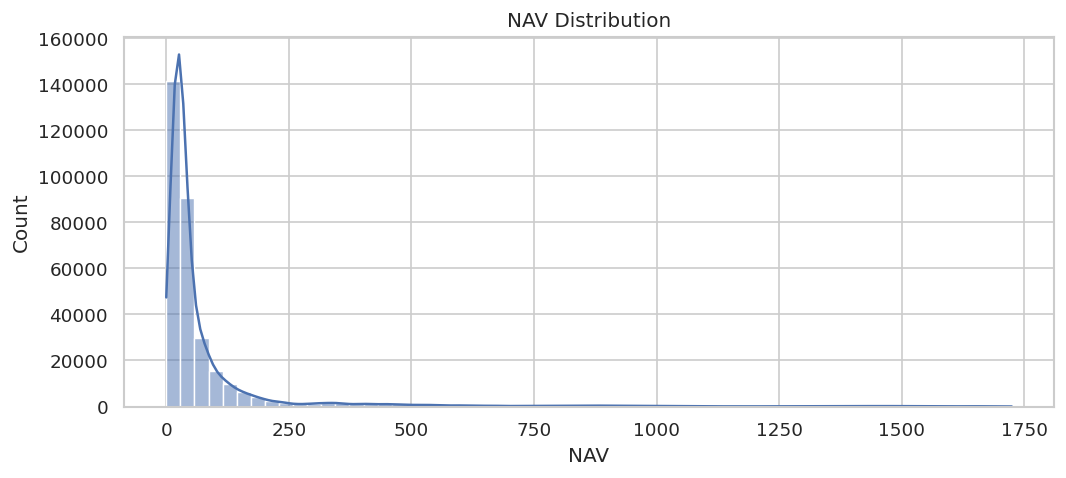

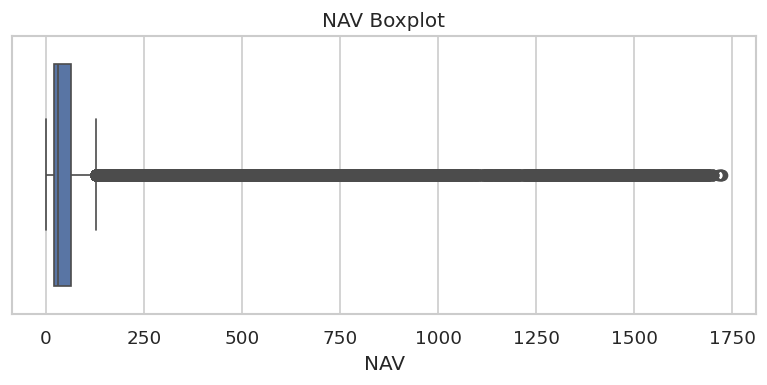

In [78]:
nav = df['NAV'].dropna()

plt.figure(figsize=(10,4))
sns.histplot(nav, kde=True, bins=60)
plt.title('NAV Distribution')
plt.show()

plt.figure(figsize=(8,3))
sns.boxplot(x=nav)
plt.title('NAV Boxplot')
plt.show()

## 5. Pivot NAV to Wide Format (for multivariate analysis)

In [79]:
df = df.sort_values(['Date','Scheme Code'])

nav_wide = df.pivot(index='Date', columns='Scheme Code', values='NAV')
nav_wide = nav_wide.apply(pd.to_numeric, errors='coerce')

sep('nav_wide shape')
print(nav_wide.shape)
display(nav_wide.head())


======== nav_wide shape ========

(4834, 269)


Scheme Code,100067,100068,100156,100174,100175,100325,100337,100338,100353,100354,...,151473,151474,151609,151610,151611,151612,153200,153201,153202,153203
Date,,,,,,,,,,,,,,,,,,,,,
2006-04-03,NaN,NaN,NaN,NaN,NaN,NaN,17.8453,20.4249,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2006-04-04,NaN,NaN,NaN,NaN,NaN,NaN,17.9515,20.5472,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2006-04-05,NaN,NaN,NaN,NaN,NaN,NaN,18.0623,20.6741,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2006-04-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2006-04-07,NaN,NaN,NaN,NaN,NaN,NaN,17.9211,20.5125,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 6. Compute Daily Returns

In [80]:
daily_ret_wide = nav_wide.pct_change()
daily_ret = daily_ret_wide.stack().rename('daily_return').reset_index().dropna(subset=['daily_return'])

sep('Sample daily returns')
display(daily_ret.head())
print('Total daily return rows:', len(daily_ret))


======== Sample daily returns ========



/tmp/ipykernel_21702/3415394504.py:1: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  daily_ret_wide = nav_wide.pct_change()


,Date,Scheme Code,daily_return
0,2006-04-04,100337,0.005951
1,2006-04-04,100338,0.005988
2,2006-04-04,101037,0.002766
3,2006-04-04,102315,0.004040
4,2006-04-04,102316,0.004337


Total daily return rows: 436862


## 7. Multivariate: Correlation Heatmap of Scheme Returns

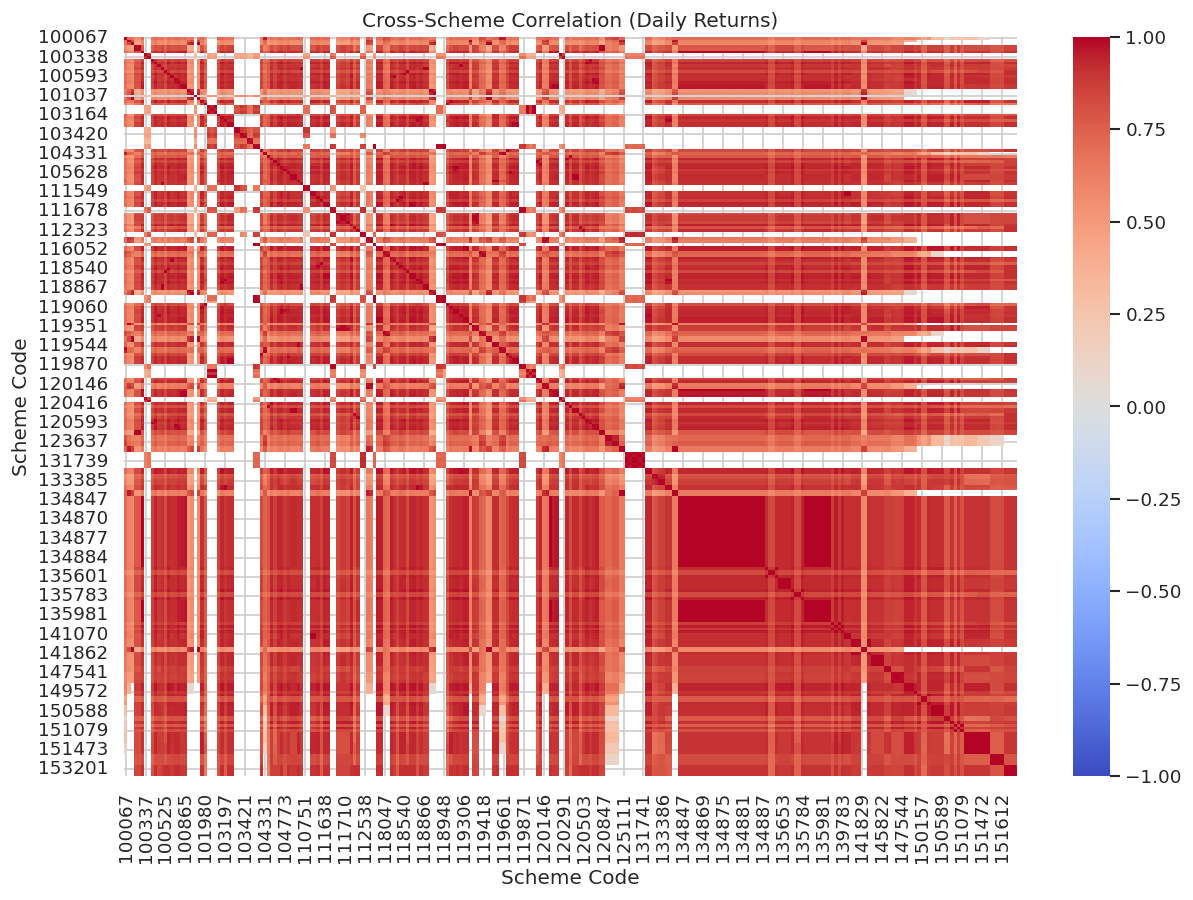

In [81]:
corr = daily_ret_wide.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Cross-Scheme Correlation (Daily Returns)')
plt.show()

## 8. Boxplot of NAV by Top 10 Schemes

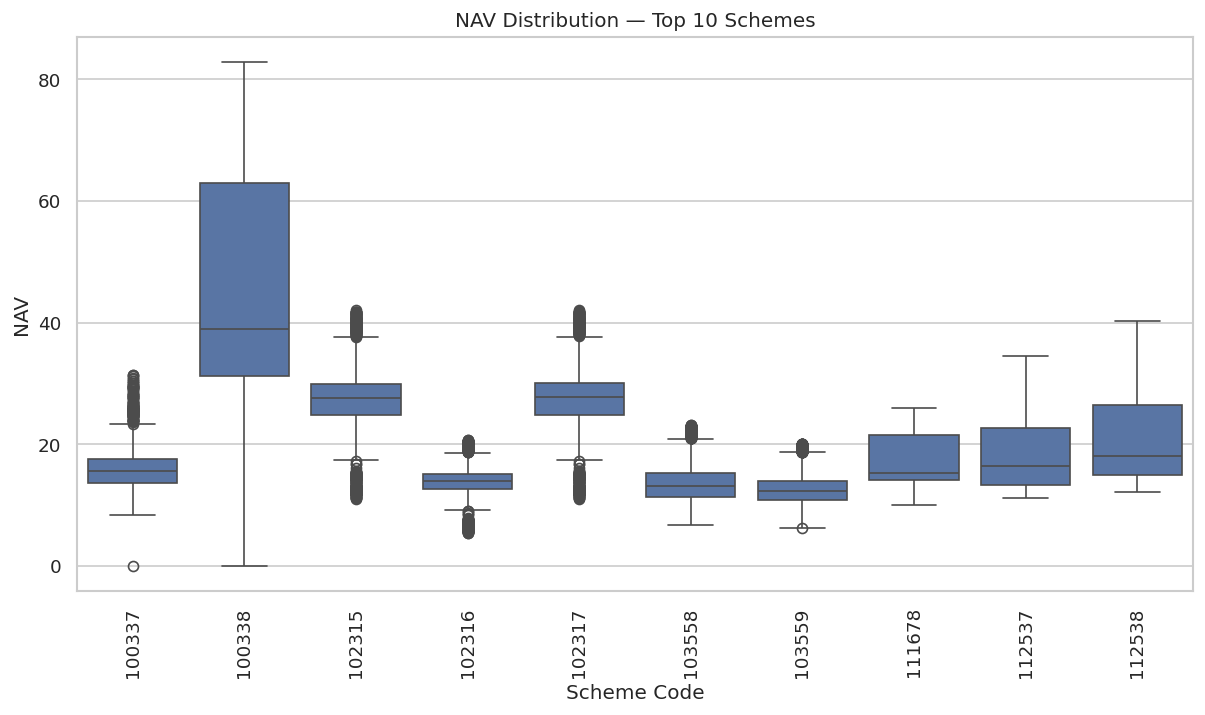

In [82]:
top10 = df['Scheme Code'].value_counts().head(10).index
df_top10 = df[df['Scheme Code'].isin(top10)]

plt.figure(figsize=(12,6))
sns.boxplot(data=df_top10, x='Scheme Code', y='NAV')
plt.xticks(rotation=90)
plt.title('NAV Distribution — Top 10 Schemes')
plt.show()

## 9. Pairplot: NAV vs Date

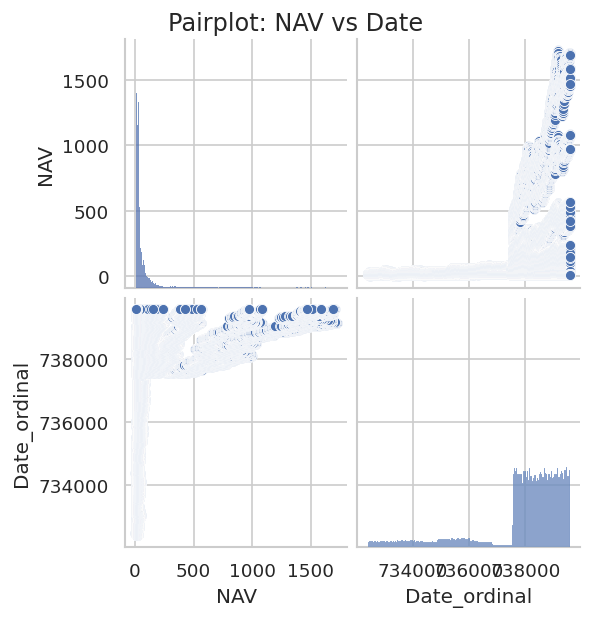

In [91]:
df['Date_ordinal'] = df['Date'].map(pd.Timestamp.toordinal)

sns.pairplot(df[['NAV','Date_ordinal']].dropna())
plt.suptitle('Pairplot: NAV vs Date', y=1.02)
plt.show()

## 10. Groupby Summary (Multivariate: Categorical → Numeric)

In [84]:
summary = df.groupby('Scheme Code')['NAV'].describe()
sep('Groupby NAV Summary by Scheme Code')
display(summary.head(10))


======== Groupby NAV Summary by Scheme Code ========



,count,mean,std,min,25%,50%,75%,max
Scheme Code,,,,,,,,
100067,732.0,91.323033,8.354307,66.1300,86.28750,92.4650,97.13250,107.0400
100068,465.0,33.449843,6.283099,20.9300,27.45000,34.0900,39.19000,44.1400
100156,416.0,255.921993,52.744136,157.3400,204.47500,261.9850,297.17500,344.0900
100174,1379.0,35.873982,12.630030,10.8920,28.54215,33.8153,48.69890,57.8769
100175,1379.0,258.469067,90.820721,78.6541,205.80735,243.6143,350.65775,416.7769
100325,1379.0,28.464219,5.871274,15.1858,25.18165,27.5826,33.93210,37.9143
100337,3447.0,15.694446,3.135194,0.0000,13.63340,15.5485,17.53205,31.4412
100338,3447.0,46.073320,19.888725,0.0000,31.14115,38.9607,62.99620,82.8861
100353,1379.0,22.130725,2.549605,14.1500,20.91000,22.3100,24.00000,27.6000
